# Variational quantum time-propagation for Burgers

Team: Andrei Poliakov, Kyro Jeremy Gibling, Nadav Carmel, Pak Tik, Sahil Ugale

Applies the same variational framework used for KdV to viscous Burgers,

$$
\partial_t u + u\,\partial_x u = \nu\,\partial_{xx} u, \qquad u(0,x)=\sin(2\pi x),
$$

periodic BC. Purpose: a validation check — the circuits are independent of any other group's
implementation (see `kdv.py`), so if they're correct, running the textbook Burgers case
should just reproduce the expected physics (steepening vs. viscous smoothing) on its own.

Uses `pde_core.py`, which generalizes the n=2-specific KdV circuits to arbitrary n (N=4
makes sin(2*pi*x)'s nonlinear term zero by aliasing, so this notebook uses n=3, N=8). The nonlinear
term is reused unchanged from KdV; the diffusion linear term is derived fresh (symmetric, unlike
KdV's skew-symmetric dispersion) and validated against a classical forward-Euler reference.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from pde_core import ansatz, get_state, get_expval_ideal, get_expval_shots, num_ansatz_params
from burgers import burgers_cost


## Problem setup

n=3 (N=8), nu=0.01 (turbulent, Re~100), u0=sin(2*pi*x), dt=0.06, 5 steps.


In [2]:
n = 3
N = 2 ** n
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]

nu = 0.01
dt = 0.06
n_steps = 5

u0 = np.sin(2 * np.pi * x)
print(f"u0 = {np.round(u0, 4)}")


u0 = [ 0.      0.7071  1.      0.7071  0.     -0.7071 -1.     -0.7071]


## Classical reference


In [3]:
from discretization import periodic_D2, construct_F2_periodic

D2 = periodic_D2(N, dx)
F2 = -1 / (2 * dx) * construct_F2_periodic(N)

classical_states = [u0.copy()]
f = u0.copy()
for _ in range(n_steps):
    f = f + dt * (nu * (D2 @ f) + F2 @ np.kron(f, f))
    classical_states.append(f.copy())
classical_states = np.array(classical_states)


## Encoding the initial state


In [4]:
nparams = num_ansatz_params(n)
amp0 = np.linalg.norm(u0)
u0_normalized = u0 / amp0


def init_loading(theta, target):
    v = np.real(Statevector(ansatz(n, theta)).data)
    return np.sum((v - target) ** 2)


best = None
for trial in range(8):
    theta0 = np.random.default_rng(trial).random(nparams) * 2 * np.pi
    res = sp.optimize.minimize(init_loading, theta0, args=(u0_normalized,), method="BFGS")
    if best is None or res.fun < best.fun:
        best = res

theta0_full = np.concatenate(([amp0], best.x))
print(f"encoding fit residual: {best.fun:.2e}")
print(f"decoded state: {np.round(get_state(n, theta0_full), 4)}")
print(f"target u0:     {np.round(u0, 4)}")


encoding fit residual: 9.46e-12
decoded state: [-0.      0.7071  1.      0.7071 -0.     -0.7071 -1.     -0.7071]
target u0:     [ 0.      0.7071  1.      0.7071  0.     -0.7071 -1.     -0.7071]


## Variational time-propagation (ideal, no shot noise)


In [5]:
def optimize_step(theta_old, seed_offset, n_restarts=6, maxiter=400):
    def objective(theta_new):
        cost, _ = burgers_cost(theta_new, theta_old, n, dt, dx, nu, get_expval_ideal)
        return cost

    best_new = None
    for trial in range(n_restarts):
        guess = theta_old + np.random.default_rng(seed_offset + trial).normal(scale=0.05, size=nparams + 1)
        res = sp.optimize.minimize(objective, guess, method="COBYLA", options={"maxiter": maxiter})
        if best_new is None or res.fun < best_new.fun:
            best_new = res
    return best_new.x, best_new.fun


theta = theta0_full.copy()
quantum_states = [get_state(n, theta)]
rel_errors = []

for step in range(n_steps):
    theta, cost = optimize_step(theta, seed_offset=1000 + 20 * step)
    decoded = get_state(n, theta)
    rel_err = np.linalg.norm(decoded - classical_states[step + 1]) / np.linalg.norm(classical_states[step + 1])
    rel_errors.append(rel_err)
    print(f"step {step+1}/{n_steps}: cost={cost:.6f}  rel. L2 error vs. classical={rel_err:.5f}")
    quantum_states.append(decoded)

quantum_states = np.array(quantum_states)


step 1/5: cost=-3.937271  rel. L2 error vs. classical=0.00004


step 2/5: cost=-3.988612  rel. L2 error vs. classical=0.00005


step 3/5: cost=-4.173111  rel. L2 error vs. classical=0.00005


step 4/5: cost=-4.462488  rel. L2 error vs. classical=0.00008


step 5/5: cost=-4.749477  rel. L2 error vs. classical=0.00015


## Results


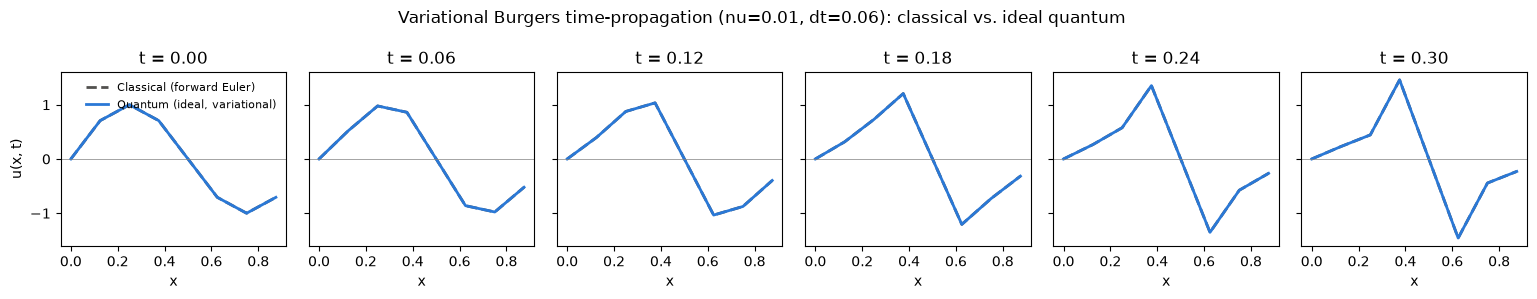

In [6]:
CLASSICAL_COLOR = "#52514e"
QUANTUM_COLOR = "#2a78d6"

fig, axes = plt.subplots(1, n_steps + 1, figsize=(2.6 * (n_steps + 1), 3.0), sharey=True)
timesteps = np.arange(n_steps + 1) * dt
for i, ax in enumerate(axes):
    ax.plot(x, classical_states[i], "--", color=CLASSICAL_COLOR, lw=2, label="Classical (forward Euler)")
    ax.plot(x, quantum_states[i], "-", color=QUANTUM_COLOR, lw=2, label="Quantum (ideal, variational)")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"t = {timesteps[i]:.2f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x, t)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Variational Burgers time-propagation (nu={nu}, dt={dt}): classical vs. ideal quantum")
fig.tight_layout()


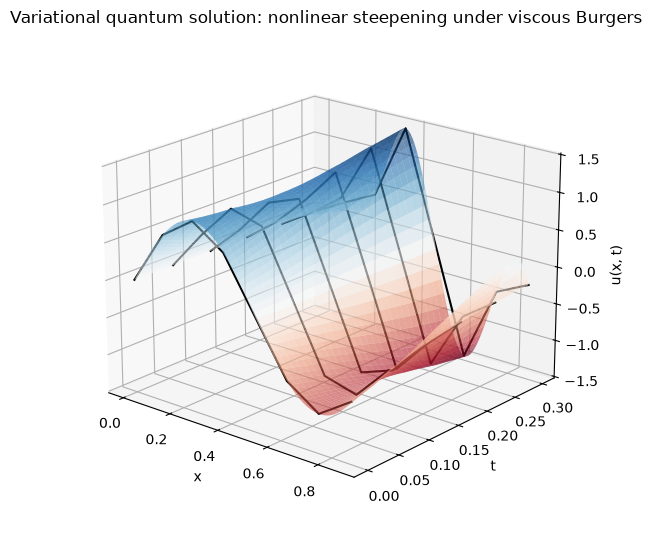

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import RectBivariateSpline


def carpet_plot(ax, x, t, U, surface_alpha=0.6, elev=20, azim=-50):
    x_fine = np.linspace(x.min(), x.max(), 150)
    t_fine = np.linspace(t.min(), t.max(), 60)
    spline = RectBivariateSpline(t, x, U, kx=1, ky=3)
    U_fine = spline(t_fine, x_fine)
    X, T = np.meshgrid(x_fine, t_fine)
    vmax = np.max(np.abs(U))
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    ax.plot_surface(X, T, U_fine, cmap="RdBu", norm=norm, linewidth=0, antialiased=True,
                     alpha=surface_alpha, rstride=2, cstride=2)
    for i, ti in enumerate(t):
        ax.plot(x, np.full_like(x, ti), U[i], color="black", lw=1.5)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    ax.set_zlabel("u(x, t)")
    ax.view_init(elev=elev, azim=azim)


fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(projection="3d")
carpet_plot(ax, x, timesteps, quantum_states)
ax.set_title("Variational quantum solution: nonlinear steepening under viscous Burgers")
fig.tight_layout()


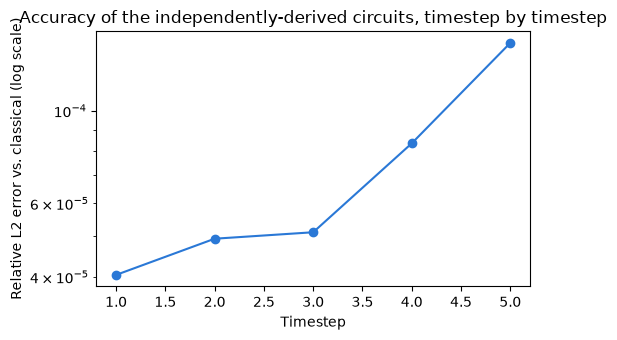

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(np.arange(1, n_steps + 1), rel_errors, "o-", color=QUANTUM_COLOR)
ax.set_yscale("log")
ax.set_xlabel("Timestep")
ax.set_ylabel("Relative L2 error vs. classical (log scale)")
ax.set_title("Accuracy of the independently-derived circuits, timestep by timestep")
fig.tight_layout()
